# Model Risk - Varational Autoencoder (VAE)

In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from arch import arch_model

import torch
import torch.nn as nn
import torch.nn.functional as F # MSE
from torch.utils.data import DataLoader, TensorDataset 

## 1. Fundamentals

### 1.1 Load data

In [2]:
returns = pd.read_csv("/Users/andre/Documents/modelrisk/data/qrm2025_returns.csv")
returns = returns.iloc[1:].reset_index(drop=True) # reset_index: Setzt den Index neu zurück; 
returns.head()

,STOXX_EU_600,DOWJONES_INDUSTRIALS,MSCI_EM,S&P_U.S._TREASURY_BOND,S&P_GSCI_Commodity
0,0.021227,0.014988,0.015312,0.001415,0.025407
1,-0.001757,-0.001128,0.010706,0.002608,0.000994
2,-0.000513,0.000798,0.006397,-0.002013,0.017457
3,-0.003961,0.003267,-0.007171,-0.000337,-0.009653
4,0.004198,0.001069,0.001962,0.001275,-0.000069


#### In-sample data

In [23]:
# In-sample data: ersten 500 Beobachtungen
returns_insample = returns[:WINDOW]
returns_insample

,STOXX_EU_600,DOWJONES_INDUSTRIALS,MSCI_EM,S&P_U.S._TREASURY_BOND,S&P_GSCI_Commodity
0,0.021227,0.014988,0.015312,0.001415,0.025407
1,-0.001757,-0.001128,0.010706,0.002608,0.000994
2,-0.000513,0.000798,0.006397,-0.002013,0.017457
3,-0.003961,0.003267,-0.007171,-0.000337,-0.009653
4,0.004198,0.001069,0.001962,0.001275,-0.000069
...,...,...,...,...,...
495,0.043870,0.025929,0.028429,-0.000084,0.013701
496,0.006797,0.003794,0.008059,-0.001108,0.013417
497,0.046435,0.042415,0.020728,-0.002670,0.006942
498,-0.005980,-0.002130,0.033185,-0.000458,-0.005439


### 1.2 Configuration

In [3]:
WINDOW = 500
# N_FORECAST = len(returns) - WINDOW
N_FORECAST = 30
N_SIM = 10000

ALPHA = 0.05, 0.01 # Signifikanzniveaus für VaR-Berechnung

SCALE = 1000 # scale factor for returns to improve GARCH convergence

SEED = 42

weights = np.ones(len(returns.columns)) / len(returns.columns)

N_FORECAST, weights

(30, array([0.2, 0.2, 0.2, 0.2, 0.2]))

In [4]:
torch.manual_seed(SEED)

### 1.3 Hyperparameter 

* β = 1   → normaler VAE
* β > 1   → stärkere Regularisierung → besseres Disentanglement
* β → 0   → normaler Autoencoder (kein Druck auf latenten Raum)

In [8]:
TRADING_DAYS_PER_YEAR = 252

In [82]:
MAX_EPOCHS     = 200
BATCH_SIZE     = 64

# NN architecture
INPUT_DIM      = 5
HIDDEN_DIMS    = (16, 16) #(64, 64): ist überparametrisiert - das NN hat zu viel Kapazität für so wenig Daten -> Overfitting/Noise/Rauschen
LATENT_DIM     = 2 # Warum 2? Bei 5 korrelierten Assets reichen 2 latente Dimensionen meist aus

BETA           = 0.5 # 0.5: weniger KL-Druck
LEARNING_RATE  = 1e-3


## 2. Functions for pipeline

### Fit marginals

Helper functions
_-Präfix: signalisiert, dass diese Funtkionen privat sind und nicht direkt von außen aufgerufen werden sollen.

fit_marginals() bleibt die einzig öffentliche Schnittstelle

In [5]:
def _extract_forecast(res, horizon, scale):
    """
    Extract mu and sigma forecast from fitted arch model.
    """
    import numpy as np

    fc = res.forecast(horizon=horizon)
    return {
        "mu":    fc.mean.iloc[-1, 0] / scale,
        "sigma": np.sqrt(fc.variance.values[-1, 0]) / scale
    }


def _extract_dist_params(params, dist):
    """
    Extract distribution parameters from fitted arch model params.
    """
    return {
        "nu":     params.get("nu")     if dist == "t"     else
                  params.get("eta")    if dist == "skewt" else None,
        "lambda": params.get("lambda") if dist == "skewt" else None
    }

Fit marginals

In [6]:
def fit_marginals(returns, garch_order=(1, 1), lags=1, dist="t", horizon=1, scale=100):
    """
    Fit an AR(lags)-GARCH(p,q) model to a single return series.

    Parameters
    ----------
    returns : pd.Series
        Raw (unscaled) return series for one asset.
    garch_order : tuple of int, optional
        (p, q) order of the GARCH volatility process. Default is (1, 1).
    lags : int, optional
        Number of autoregressive lags in the mean equation. Default is 1.
    dist : str, optional
        Innovation distribution. One of 'normal', 't', or 'skewt'. Default is 't'.
    horizon : int, optional
        Forecast horizon in periods. Default is 1.
    scale : float, optional
        Multiplicative scaling applied before fitting for numerical stability.
        All forecasts are rescaled back to the original units.

    Returns
    -------
    dict with keys:
        residuals_std : pd.Series   -- standardized residuals; first row is NaN
        mu            : float       -- one-step-ahead mean forecast
        sigma         : float       -- one-step-ahead volatility forecast
        nu            : float|None  -- degrees of freedom, else None
        lambda        : float|None  -- skewness parameter in (-1, 1) for 'skewt', else None
    """
    from arch import arch_model

    p, q = garch_order
    res = arch_model(returns*scale, mean="AR", lags=lags, vol="Garch", p=p, q=q, dist=dist).fit(disp="off", show_warning=False)

    return {
        "residuals_std": res.std_resid,
        **_extract_forecast(res, horizon, scale),
        **_extract_dist_params(res.params, dist)
    }

### Removing NaNs from matrix_residuals_std

In [7]:
def _drop_nan_rows(matrix):
    """
    Drop rows containing any NaN value.
    """
    return matrix[~np.isnan(matrix).any(axis=1)]

#### Test

In [8]:
test_marginals = fit_marginals(returns["DOWJONES_INDUSTRIALS"])
test_marginals["residuals_std"]

0            NaN
1      -0.174970
2      -0.020122
3       0.327778
4       0.040394
          ...   
2341   -0.099587
2342    2.697244
2343    0.466872
2344   -0.155349
2345    0.470817
Name: std_resid, Length: 2346, dtype: float64

In [62]:
torch.manual_seed(SEED)
fits = {c: fit_marginals(returns_insample[c], scale=SCALE, dist="skewt") for c in returns.columns}

In [55]:
fits

{'STOXX_EU_600': {'residuals_std': 0           NaN
  1     -0.245299
  2     -0.075663
  3     -0.398270
  4      0.368628
           ...   
  495    2.117319
  496    0.218975
  497    2.070812
  498   -0.315939
  499    0.257825
  Name: std_resid, Length: 500, dtype: float64,
  'mu': np.float64(0.0005826200828544879),
  'sigma': np.float64(0.022862887450299834),
  'nu': np.float64(8.806033996222252),
  'lambda': np.float64(-0.06786548769958362)},
 'DOWJONES_INDUSTRIALS': {'residuals_std': 0           NaN
  1     -0.191242
  2     -0.030354
  3      0.299191
  4      0.023350
           ...   
  495    1.761890
  496    0.225515
  497    2.753426
  498   -0.082764
  499   -0.057673
  Name: std_resid, Length: 500, dtype: float64,
  'mu': np.float64(0.00100824428391114),
  'sigma': np.float64(0.018162583573953645),
  'nu': np.float64(4.68935230490914),
  'lambda': np.float64(-0.08954992258627735)},
 'MSCI_EM': {'residuals_std': 0           NaN
  1      0.725990
  2      0.392463
  3    

In [56]:
fits['STOXX_EU_600'], fits['STOXX_EU_600']["residuals_std"]

({'residuals_std': 0           NaN
  1     -0.245299
  2     -0.075663
  3     -0.398270
  4      0.368628
           ...   
  495    2.117319
  496    0.218975
  497    2.070812
  498   -0.315939
  499    0.257825
  Name: std_resid, Length: 500, dtype: float64,
  'mu': np.float64(0.0005826200828544879),
  'sigma': np.float64(0.022862887450299834),
  'nu': np.float64(8.806033996222252),
  'lambda': np.float64(-0.06786548769958362)},
 0           NaN
 1     -0.245299
 2     -0.075663
 3     -0.398270
 4      0.368628
          ...   
 495    2.117319
 496    0.218975
 497    2.070812
 498   -0.315939
 499    0.257825
 Name: std_resid, Length: 500, dtype: float64)

In [63]:
# to_numpy(): konvertiert eine pd.Series in ein reines Numpy-Array
matrix_residuals_std = _drop_nan_rows(np.column_stack([fits[c]["residuals_std"].to_numpy()
                                        for c in returns.columns]))
matrix_residuals_std

array([[-0.24529906, -0.19124205,  0.72599007,  1.24515424, -0.02915629],
       [-0.07566311, -0.03035449,  0.39246335, -1.05666846,  1.36476659],
       [-0.39827038,  0.29919124, -0.91884869, -0.33979934, -0.83081968],
       ...,
       [ 2.07081173,  2.7534259 ,  1.15385207, -1.42548133,  0.46249759],
       [-0.31593854, -0.08276418,  1.74981099, -0.38795804, -0.49348323],
       [ 0.25782477, -0.05767296, -0.29336193,  1.03572974,  0.44927517]],
      shape=(499, 5))

### VAE model

* the VAE maps each x to a Gaussian distribution with mu and sigma over ltatent space; a plain autoencoder maps each input x to a single point z in latent space
* loss function has 2 terms: 1. reconstruction loss 2. KL divergence
* KL divergence: the KL term compares the encoder's output distribution mu and sigma to the Gaussian standard normal distribution. The closer they are, the smaller the KL
* Beta: hyperparameter which weights the KL term. Higher beta means more pressure on the latent space to look Gaussian, at the cost of worse reconstruction (higher reconstruction loss)
------------------------------------------------------------------------------------------------------------------------




Architecture in pseudo-diagram form:

```
x (5-dim)  ──▶  Linear(5, 64)  ──▶  tanh  ──▶  hidden (64-dim)
                                                     │
                                          ┌──────────┴──────────┐
                                          ▼                     ▼
                                    Linear(64, 3)         Linear(64, 3)
                                    = mu                  = log_var
                                          │                     │
                                          └──── sample z ───────┘
                                                z = mu + sigma * eps
                                                eps ~ N(0, 1)
                                                     │
                                                     ▼
                                              z (3-dim)
                                                     │
                                                     ▼
                                          Linear(3, 64)  ──▶  tanh  ──▶  Linear(64, 5)
                                                                              │
                                                                              ▼
                                                                         x_hat (5-dim)
```

#### Conventions

**Stack**
„Stack" bedeutet einfach mehrere Schichten, die hintereinander gestapelt sind – eine nach der anderen.

Der Begriff kommt aus der Informatik – wie ein Stapel Pfannkuchen, bei dem man immer oben drauflegt. Im Deep Learning sagt man „stacked layers" oder einfach „stack", wenn man mehrere Schichten übereinander schichtet.

```
self.encoder = nn.Sequential(
    nn.Linear(input_dim, hidden_dims[0]),  # Schicht 1
    nn.Tanh(),                             # Schicht 2
    nn.Linear(hidden_dims[0], hidden_dims[1]),  # Schicht 3
    nn.Tanh(),                             # Schicht 4
)
```

Das nn.Sequential ist dabei der „Stack" – es stapelt die Schichten so, dass der Output von Schicht 1 automatisch zum Input von Schicht 2 wird, usw:

--------------------------------------------------------------------------------------------------------------------
**Wrapper**
Ein Wrapper ist eine Funktion, die eine andere Funktion *einwickelt* - also nichts weiter tut, als sie aufzurufen.

#### VAE class

In [19]:
class VAE_model(nn.Module):
    """
    VAE architecture:
        - 2 hidden layers x 64 neurons with Tanh activations
        - latent dimension = 3
        - Beta = 2
        - MSE reconstruction

    Gesamtbild: Training vs. Generierung
    Training:     x → encode → reparameterize → decode → x̂  (+Loss)
    Generierung:  𝒩(0,I) ──────────────────── decode → x̂
    """
    def __init__(self, input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, latent_dim=LATENT_DIM, beta=BETA): # Initialisierung des Modells
        super().__init__() # ruft den Konstruktor von nn.Module auf
        
        self.latent_dim = latent_dim
        self.beta       = beta

        # Encoder: x -> hidden -> tanh -> hidden -> tanh
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.Tanh(), # Aktivierungsfunktion: Werte werden auf [-1, 1] begrenzt
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.Tanh()
        )

        # VAE-specific part: LATENT SPACE
        # Hidden layer wird in eine Verteilung (mu, sigma bzw. log_var) zerlegt, nicht in einen festen Wert
        # Warum mu und sigma? 
            # Es wird nicht modelliert: x -> z
            # sondern (Kern des VAE): x → (μ(x), σ²(x))
            # zusammen parametriesieren sie eine Gaussian dist
        self.encoder_mu     = nn.Linear(hidden_dims[1], latent_dim)
        self.encoder_logvar = nn.Linear(hidden_dims[1], latent_dim)

        # Decoder mirrors encoder
        # Decoder bekommt einen einzelnen Punkt z als Input, der aus einer Verteilung gesampelt wurde
            # 1. Encoder erzeugt Verteilung
            # 2. Aus der Verteilung wird ein Punkt z gesampelt
            # 3. Dieser Punkt z geht in den Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims[1]),
            nn.Tanh(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.Tanh(),
            nn.Linear(hidden_dims[0], input_dim)
        )

    # Function for the encoder
    def encode(self, x):
        h = self.encoder(x) # schickt Input durch den sequenziellen Encoder-Stack -> Output: Vektor h
        return self.encoder_mu(h), self.encoder_logvar(h)

    # Function for the decoder
    # Simpler Wrapper: schickt latenten Vektor z durch den Decoder und gibt Rekonstrktion x_hat zurück
    def decode(self, z):
        return self.decoder(z)

    
    # Reparameterization trick
    # Problem: um z zu sampeln braucht man eine zufällige Operation z ~ 𝒩(μ, σ²) 
        #  – aber durch Zufall kann kein Gradient fließen, also kein Backprop möglich
    # Trick: man lagert die Zufälligkeit in ein seperates eps ε ~ 𝒩(0, I) aus 
        # und schreibt stattdessen z = μ + σ · ε – ε ist jetzt der zufällige Teil, 
        # aber die Gradienten fließen sauber durch μ und σ
    # Ergebnis: Das Netz kann lernen, weil μ und σ differenzierbar im Rechengraphen stecken 
        # – ε ist nur „externes Rauschen" das dazuaddiert wird
    def reparameterize(self, mu, logvar):
        """
        z = mu + sigma * eps,  eps ~ N(0, I)
        Reparameterization trick: keeps the random draw outside the
        differentiable path so gradients flow through mu and sigma.
        """
        sigma = torch.exp(0.5 * logvar)
        eps   = torch.randn_like(sigma)
        return mu + sigma * eps


    # Forward pass/Forwardprop
    # komplette Vorwärtsdurchlauf in 3 Schritten
        # x -> encode() -> (μ, log σ²) → reparameterize() → z → decode() → x̂
        # μ und log σ² werden zusätzlich zurückgegeben, weil die Loss-Funktion sie für den KL-Term braucht:
        # Loss = Rekonstruktionsfehler(x, x̂) + β · KL(q(z|x) || p(z))
    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


    # Sampling
    @torch.no_grad() # Deaktiviert den Gradientengraphen -> Wir generieren nur, kein Training → spart Speicher
    def sampling(self, n):
        z = torch.randn(n, self.latent_dim) # Sampelt n Vektoren aus 𝒩(0, I)
        return self.decode(z) # Decoder erzeugt n synthetische Datenpunkte -> reine Generierung, kein Encoder nötig


#### VAE loss function

**Posterior collapse** 
* Der Encoder lernt, unbabhängig vom Input immer dieselbe Verteilung auszugeben:
    * x₁ → Encoder → 𝒩(0, I)
    * x₂ → Encoder → 𝒩(0, I)   ← egal was reinkommt
    * x₃ → Encoder → 𝒩(0, I)
* Der latetne Raum enthält somit keine Information mehr über die Eingabe - er ist kollabiert auf den Prior
* Warum passiert das? Die zwei Loss-Terme kämpfen gegeneinander
    * recon-Loss  →  will z so informativ wie möglich
    * KL-Loss     →  will q(z|x) so nah wie möglich an 𝒩(0, I)
    * Wenn der Decoder stark genug ist, lernt er die Rekonstruktion ohne den latenten Raum zu nutzen – weil es für den KL-Term „bequemer" ist, einfach μ=0, σ=1 zurückzugeben.
* Woran erkennt man es? Im Trianing-Log:
    * Normal: recon sinkt + kl sinkt, stabilisert sich
    * **Posterior collapse**: recon sinkt weiter + kl geht gegen 0 -> Encoder hat aufgehört eine sinnvolle Verteilung u lernen und gibt immer μ=0, σ=1 zurück
* Warum ist das schlimm?
    * Ein kollabierter VAE kann zwar rekonstruieren, aber **nicht sinnvoll sampeln**
    * weil der latente Raum keine strukturierte Bedeutung mehr hat
    * Das Modell ist dann praktisch nur noch ein normaler Autoencoder


In [20]:
def vae_loss_components(x, x_hat, mu, lv, beta=1.0):
    """
    Return (total, recon, kl) so we can monitor them separately.
    Posterior collapse shows up as kl -> 0 while recon keeps improving.
    """
    recon = F.mse_loss(x_hat, x, reduction="mean") # misst wie gut der Decoder die Inputdaten rekonstruiert hat 
    kl    = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp()) # Das Vorzeichen -0.5 dreht den Term um, weil wir minimieren (Loss), die KL-Formel aber ursprünglich maximiert wird
    total = recon + beta * kl # Die zwei Terme werden addiert, wobei β den KL-Term skaliert; ß>1: stärkere Regularisierung
    return total, recon, kl # alle 3 Wert ewerden zurückgegeben, damit während dem Training beobachtet werden kann, ob ein Posterior Collapse passiert

#### VAE train

Muster sieht typischerweise so aus:
```
model.train()          # einmal vor der Trainingsloop
for epoch in ...:
    for x in loader:
        ...            # Training

    # optional: Validierung nach jeder Epoche
    model.eval()
    with torch.no_grad():
        ...            # Validierung
    model.train()      # zurück in den Trainings-Modus!
```

In [42]:
def VAE_train(model, dataset, epochs: int = 50, batch_size: int = 128, lr: float = 1e-3,
    device: str = "cpu",
    log_every: int = 1,          # Epochen-Intervall für Konsolenausgabe
    save_path: str | None = None, # z. B. "checkpoints/vae_best.pt"
):
    """
    Trainingsloop für den VAE.

    Args:
        model:      Instanz von VAE_model
        dataset:    torch.utils.data.Dataset
        epochs:     Anzahl Trainingsepochen  (frei wählbar)
        batch_size: Batch-Größe              (frei wählbar)
        lr:         Lernrate für Adam
        device:     "cpu" oder "cuda"
        log_every:  nach wie vielen Epochen geloggt wird
        save_path:  Falls angegeben, wird das Modell mit bestem Loss gespeichert
    """

    # --- Typ-Konvertierung ---
    if isinstance(dataset, pd.DataFrame):
        dataset = torch.tensor(dataset.values, dtype=torch.float32)
    elif not isinstance(dataset, torch.Tensor):
        dataset = torch.tensor(dataset, dtype=torch.float32)

    loader = DataLoader(TensorDataset(dataset), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Optimizer: Adam
    model.to(device)
    model.train()

    best_loss = float("inf")
    history = {"total": [], "recon": [], "kl": []}

    for epoch in range(1, epochs + 1):
        # --- Akkumulatoren für diese Epoche ---
        epoch_total = epoch_recon = epoch_kl = 0.0

        for (x, ) in loader:
            x = x.to(device)

            # 1. Forward Pass
            x_hat, mu, lv = model(x)

            # 2. Loss berechnen (alle 3 Terme zurückbekommen)
            total, recon, kl = vae_loss_components(x, x_hat, mu, lv, beta=model.beta)

            # 3. Gradienten nullsetzen → Backprop → Gewichte aktualisieren
            optimizer.zero_grad()
            total.backward()
            optimizer.step()

            # Batchverluste aufsummieren (detach verhindert Speicherleck)
            epoch_total += total.item()
            epoch_recon += recon.item()
            epoch_kl    += kl.item()

        # Auf Epochen-Mittelwert normieren
        n_batches = len(loader)
        epoch_total /= n_batches
        epoch_recon /= n_batches
        epoch_kl    /= n_batches

        history["total"].append(epoch_total)
        history["recon"].append(epoch_recon)
        history["kl"].append(epoch_kl)

        # --- Logging ---
        if epoch % log_every == 0:
            print(
                f"Epoch {epoch:>4}/{epochs} | "
                f"Loss {epoch_total:.4f} | "
                f"Recon {epoch_recon:.4f} | "
                f"KL {epoch_kl:.4f}"
            )

        # --- Posterior Collapse früh erkennen ---
        # KL < 0.01 bei noch hohem Recon-Loss ist ein Warnsignal
        if epoch_kl < 0.01 and epoch_recon > 0.5:
            print(f"  ⚠ Möglicher Posterior Collapse in Epoche {epoch}!")

        # --- Checkpoint speichern (bestes Modell) ---
        if save_path is not None and epoch_total < best_loss:
            best_loss = epoch_total
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "loss": best_loss}, save_path)

    return history  # für Plots nutzbar

#### VAE application

In [77]:
# Standardized residuals matrix froim returns_insample
matrix_residuals_std

array([[-0.24529906, -0.19124205,  0.72599007,  1.24515424, -0.02915629],
       [-0.07566311, -0.03035449,  0.39246335, -1.05666846,  1.36476659],
       [-0.39827038,  0.29919124, -0.91884869, -0.33979934, -0.83081968],
       ...,
       [ 2.07081173,  2.7534259 ,  1.15385207, -1.42548133,  0.46249759],
       [-0.31593854, -0.08276418,  1.74981099, -0.38795804, -0.49348323],
       [ 0.25782477, -0.05767296, -0.29336193,  1.03572974,  0.44927517]],
      shape=(499, 5))

In [70]:
torch.manual_seed(SEED)
model = VAE_model()
history = VAE_train(model, matrix_residuals_std, epochs=100, batch_size=32, log_every=1)

Epoch    1/100 | Loss 1.0176 | Recon 0.9972 | KL 0.0102
Epoch    2/100 | Loss 0.9995 | Recon 0.9801 | KL 0.0097
  ⚠ Möglicher Posterior Collapse in Epoche 2!
Epoch    3/100 | Loss 1.0088 | Recon 0.9527 | KL 0.0281
Epoch    4/100 | Loss 0.9740 | Recon 0.8805 | KL 0.0468
Epoch    5/100 | Loss 0.9315 | Recon 0.7876 | KL 0.0720
Epoch    6/100 | Loss 0.9248 | Recon 0.7734 | KL 0.0757
Epoch    7/100 | Loss 0.9362 | Recon 0.7776 | KL 0.0793
Epoch    8/100 | Loss 0.9129 | Recon 0.7346 | KL 0.0891
Epoch    9/100 | Loss 0.9682 | Recon 0.7709 | KL 0.0987
Epoch   10/100 | Loss 0.9375 | Recon 0.7435 | KL 0.0970
Epoch   11/100 | Loss 0.9314 | Recon 0.7247 | KL 0.1034
Epoch   12/100 | Loss 0.9475 | Recon 0.7336 | KL 0.1069
Epoch   13/100 | Loss 0.9293 | Recon 0.7332 | KL 0.0980
Epoch   14/100 | Loss 0.9474 | Recon 0.7674 | KL 0.0900
Epoch   15/100 | Loss 0.9479 | Recon 0.7268 | KL 0.1105
Epoch   16/100 | Loss 0.9491 | Recon 0.7455 | KL 0.1018
Epoch   17/100 | Loss 0.9335 | Recon 0.7615 | KL 0.0860
Ep

#### VAE plot results

In [50]:
def plot_vae_history(history):
    epochs = range(1, len(history["total"]) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, key, color, title in zip(
        axes,
        ["total", "recon", "kl"],
        ["steelblue", "seagreen", "tomato"],
        ["Total Loss", "Reconstruction Loss", "KL Divergence"]
    ):
        ax.plot(epochs, history[key], color=color, linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)
    
    plt.suptitle("VAE Training History", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

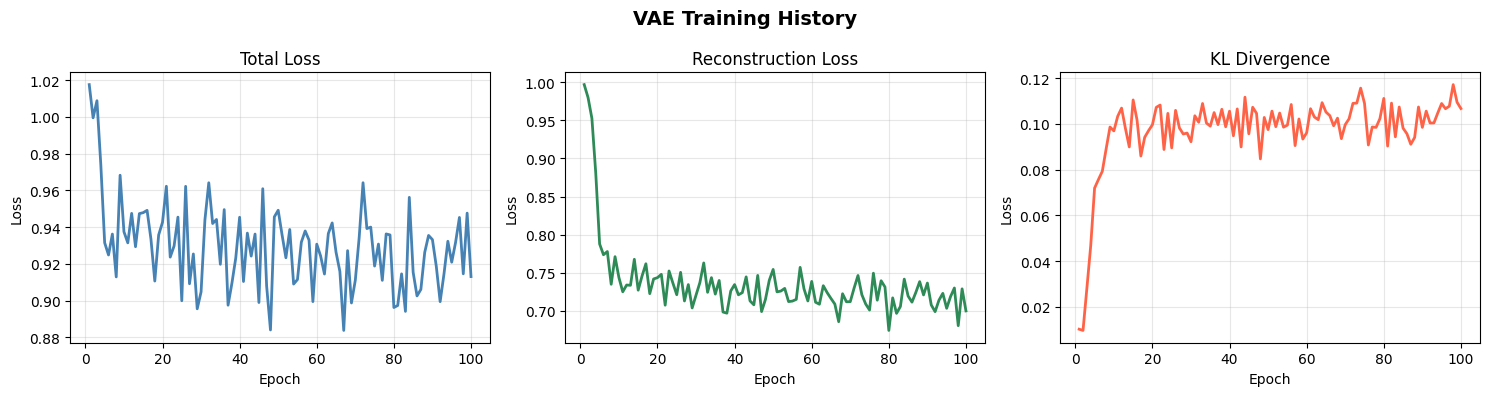

In [71]:
plot_vae_history(history)

Interpretation:
* Loss flacht ab ~Epoche 10: Modell stagniert früh
* Starkes Rauschen (z.B. 0.90 → 0.97 → 0.91): Batch-Varianz sehr hoch
* Recon nach 100 Epochen noch bei 0.70: Konvergenz sehr langsam

#### VAE application 2.

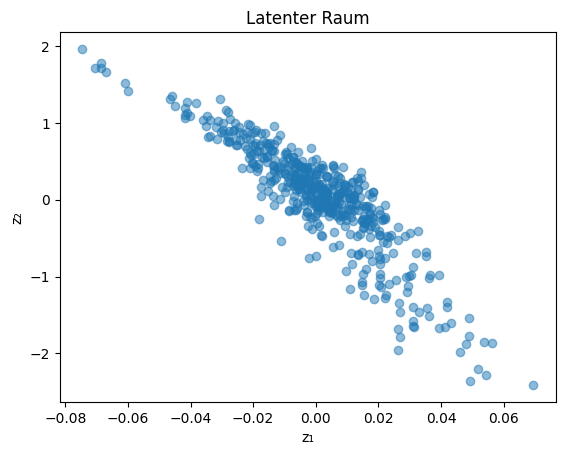

In [81]:
# Latenten Raum visualisieren
model.eval()
with torch.no_grad():
    data = torch.tensor(matrix_residuals_std, dtype=torch.float32)
    mu, _ = model.encode(data)

plt.scatter(mu[:, 0], mu[:, 1], alpha=0.5)
plt.xlabel("z₁"); plt.ylabel("z₂")
plt.title("Latenter Raum")
plt.show()

In [84]:
torch.manual_seed(SEED)
model = VAE_model()
history2 = VAE_train(model, matrix_residuals_std, epochs=300, batch_size=64, log_every=1, lr=1e-3)

Epoch    1/300 | Loss 1.0275 | Recon 1.0053 | KL 0.0111
Epoch    2/300 | Loss 0.9998 | Recon 0.9883 | KL 0.0058
  ⚠ Möglicher Posterior Collapse in Epoche 2!
Epoch    3/300 | Loss 1.0186 | Recon 1.0027 | KL 0.0080
  ⚠ Möglicher Posterior Collapse in Epoche 3!
Epoch    4/300 | Loss 1.0039 | Recon 0.9875 | KL 0.0082
  ⚠ Möglicher Posterior Collapse in Epoche 4!
Epoch    5/300 | Loss 0.9780 | Recon 0.9526 | KL 0.0127
Epoch    6/300 | Loss 0.9556 | Recon 0.9120 | KL 0.0218
Epoch    7/300 | Loss 0.9513 | Recon 0.8486 | KL 0.0514
Epoch    8/300 | Loss 0.9466 | Recon 0.8175 | KL 0.0646
Epoch    9/300 | Loss 0.9793 | Recon 0.8217 | KL 0.0788
Epoch   10/300 | Loss 0.9624 | Recon 0.8144 | KL 0.0740
Epoch   11/300 | Loss 0.9341 | Recon 0.7968 | KL 0.0687
Epoch   12/300 | Loss 0.9591 | Recon 0.8203 | KL 0.0694
Epoch   13/300 | Loss 0.9641 | Recon 0.8126 | KL 0.0758
Epoch   14/300 | Loss 0.9419 | Recon 0.8164 | KL 0.0628
Epoch   15/300 | Loss 0.9560 | Recon 0.7852 | KL 0.0854
Epoch   16/300 | Loss 

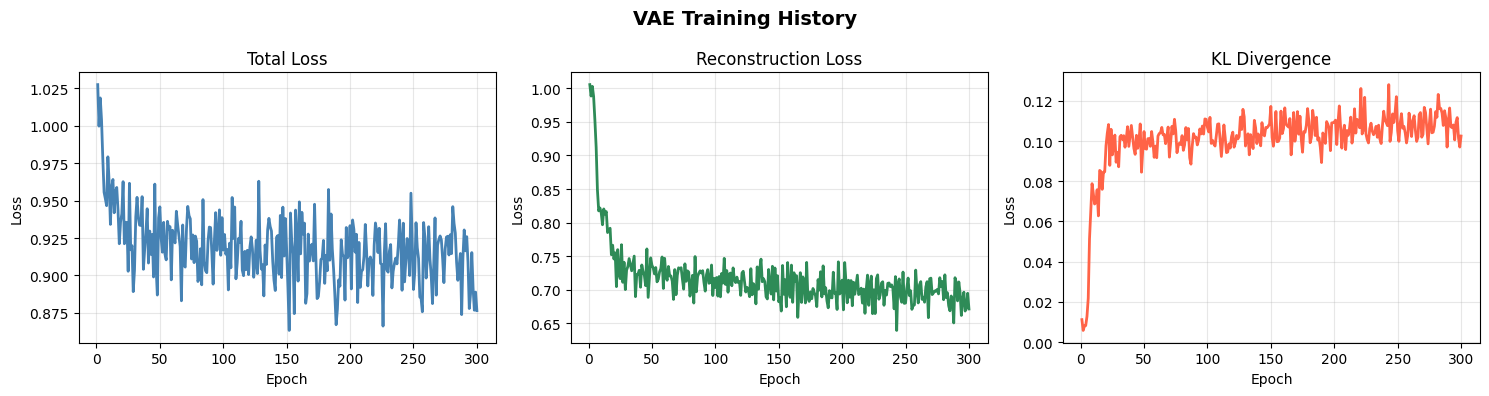

In [85]:
plot_vae_history(history2)

Modell konvergiert schlicht nicht weiter. Nach Epoche 30 passiert nichts mehr Substanzielles.

## 3. Main pipeline

In [ ]:
def main(returns, weights, window, n_forecast, n_sim, dist="t"):
    """
    Rolling window VaR forecasting pipeline.

    For each t in  0..n_forecast-1:
        1. Take the rolling window returns[t:t+window].
        2. Fit AR(1)-GARCH(1,1)-t per asset -> standardized residuals, mu & sigma forecasts, dist param nu.

    """
    for t in range(n_forecast):

        window_returns = returns.iloc[t:t+WINDOW] # rolling window of returns for model fitting

        # --- 1. Fit marginals ------------------------------------------------------
        fits = {c: fit_marginals(returns[c], scale=SCALE, dist=dist) for c in returns.columns}

        # Extract standardized residuals
        matrix_residuals_std = _drop_nan_rows(np.column_stack([fits[c]["residuals_std"].to_numpy() for c in returns.columns]))

        # Extract forecast values 
        mu = np.column_stack([f["mu"] for f in fits.values()]) # Mean forecast for the day ahead
        sigma = np.column_stack([f["sigma"] for f in fits.values()]) # Volatility forecast for the day ahead

        # Extract dist params
        nu = np.column_stack([f["nu"] for f in fits.values()]) # nu: degrees of freedom for the t-distribution


        # --- 2. VAE refit ---------------------------------------------------













